# Condition-specific promoter optimization

This notebook evolves a 600 bp promoter inside a plasmid context.

Each candidate promoter is evaluated under two biological conditions:

- **On-target:** glioblastoma
- **Off-target:** pancreas

The fitness score is calculated as:

$$
\mathrm{fitness}
=
\mathrm{mean\ on\text{-}target\ score}
-
\mathrm{mean\ off\text{-}target\ score}
$$

A candidate receives a high fitness score when it produces:

- strong predicted ATAC-seq signal in glioblastoma;
- weak predicted ATAC-seq signal in pancreas.

Evolution therefore searches for promoter sequences with condition-specific predicted activity.

In [ ]:
import os
import random
from collections.abc import Iterable, Sequence
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

from gena_expression import (
    AnnotatedSequence,
    DescriptionLookup,
    Feature,
    PlasmidRecord,
    SequenceModel,
    TrackFeatureScorer,
)
from gena_expression.optimization import SequenceOptimizer
from gena_expression.dna.plasmid import centered_plasmid_window

from gena_expression.scoring.scorers import (
    ExpressionScorer,
    ScorerSet,
    TrackFeatureScorer,
    TrackWindowScorer,
)

## Configuration

The following paths identify the expression-model implementation, checkpoint,
tokenizers, condition descriptions, and plasmid cache.

Change the paths and CUDA device to match the environment in which the notebook
is running. A single random seed is also defined so that the starting promoter,
initial population, and evolutionary operators are reproducible.

In [ ]:
# Paths and constants used by later cells

from pathlib import Path

GENALM_HOME = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark")

os.environ["GENALM_HOME"] = GENALM_HOME.__str__()

GENA_LM_ROOT = GENALM_HOME / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_FILE = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_FILE}::ExpressionCounts"

MODEL_CHECKPOINT = GENALM_HOME / "models" / "expression_model_v1-1" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / 'configs' / "final.yaml" # CHANGE THIS LINE
#MODEL_CONFIG = Path("/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments") / "GENA_LM" / "downstream_tasks" / "expression_prediction" / 'configs' / "final.yaml"
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DATA_DIR = Path("../data").resolve()
#DESCRIPTION_DIR = DATA_DIR / "real_descriptions"
DESCRIPTION_DIR = Path('/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata')

PLASMID_STORAGE = Path('/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/data/plasmids')

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:1" # CHANGE THIS LINE


TOKEN_LEN_FOR_FETCH = 15
NUM_BEFORE = 512
DNA_MAX_SEQ_LEN = 1024
DESC_MAX_SEQ_LEN = 510
RANDOM_SEED=42

## Load the expression model

`SequenceModel.load()` loads the model class, configuration, checkpoint, DNA
tokenizer, description tokenizer, and inference device.

The model will later tokenize every candidate relative to the reporter TSS.

In [8]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=DNA_MAX_SEQ_LEN,
    num_before=NUM_BEFORE,
    desc_max_seq_len=DESC_MAX_SEQ_LEN,
    token_len_for_fetch=TOKEN_LEN_FOR_FETCH,
    device=DEVICE,
)

ValueError: Dataset config 'train_dataset_ATAC_mouse' has no valid *target*

## Define the biological conditions

`DescriptionLookup` selects the metadata record associated with each ENCODE
identifier and converts it into a `Condition`.

The condition objects are constructed once and reused throughout the notebook.
`strict=True` causes missing identifiers to fail immediately instead of
producing an error later during prediction.

In [4]:
ON_TARGET_KEY = "ENCFF035CWS"   # Glioblastoma
OFF_TARGET_KEY = "ENCFF083EOC"  # Pancreas

lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=[ON_TARGET_KEY, OFF_TARGET_KEY],
    seed=RANDOM_SEED,
    strict=True,
)

on_target_condition = lookup.condition(ON_TARGET_KEY)
off_target_condition = lookup.condition(OFF_TARGET_KEY)

## Load the plasmid

The plasmid is downloaded from NCBI on the first run and cached in
`PLASMID_STORAGE`. Its GenBank features are converted into an
`AnnotatedSequence`.

The annotation plot is a useful check that the reporter and cloning-site
features were parsed correctly before modifying the sequence.

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Downloaded plasmid annotations'}, xlabel='Sequence coordinate'>)

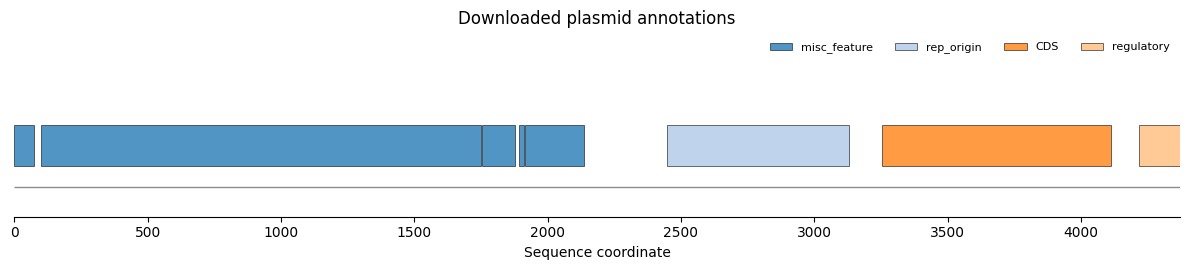

In [5]:
plasmid = PlasmidRecord.from_ncbi(
    ncbi_url="https://www.ncbi.nlm.nih.gov/nuccore/MK484104.1",
    data_storage=PLASMID_STORAGE,
    reporter_feature_name="luc2",
)

# Convert the record only once and reuse the annotated sequence.
plasmid_sequence = plasmid.annotated_sequence()

plasmid_sequence.plot_annotations(
    label_features=False,
    title="Downloaded plasmid annotations",
)

## Construct the optimization sequence

A reproducible random 600 bp promoter is inserted in place of the annotated
cloning site.

The reporter TSS is added before replacement. `AnnotatedSequence.replace()`
preserves the inserted promoter annotation and shifts downstream annotations
when the replacement changes the plasmid length.

Finally, the circular plasmid is rotated so that the reporter TSS is at the
center. This TSS-centered sequence is used consistently for both evolution and
the final comparison.

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'TSS-centered plasmid with evolvable promoter'}, xlabel='Sequence coordinate'>)

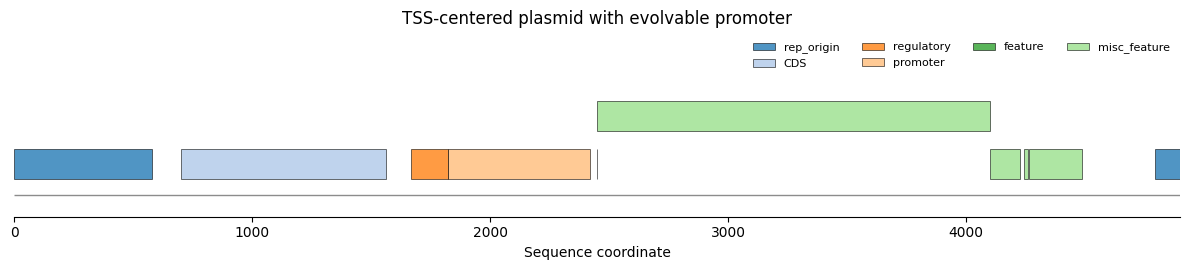

In [6]:
PROMOTER_LENGTH = 600
DNA_ALPHABET = "ACGT"


def random_dna(length: int, rng: random.Random) -> str:
    """Return a random DNA string using the supplied reproducible RNG."""

    return "".join(
        rng.choice(DNA_ALPHABET)
        for _ in range(length)
    )


# Require exactly one cloning-site annotation.
mcs_matches = [
    feature
    for feature in plasmid_sequence.features
    if "cloning site" in feature.name.lower()
]

if len(mcs_matches) != 1:
    raise ValueError(
        "Expected exactly one cloning-site feature, "
        f"but found {len(mcs_matches)}."
    )

mcs_feature = mcs_matches[0]

# Use a dedicated RNG for the starting promoter.
promoter_rng = random.Random(RANDOM_SEED)

initial_promoter = AnnotatedSequence(
    sequence=random_dna(PROMOTER_LENGTH, promoter_rng),
    name="promoter",
    features=[
        Feature(
            name="promoter",
            start=0,
            end=PROMOTER_LENGTH,
            type="promoter",
        )
    ],
)

reporter_tss = plasmid.reporter_tss_index()

plasmid_with_promoter = (
    plasmid_sequence
    .add_feature(
        name="tss",
        start=reporter_tss,
        end=reporter_tss + 1,
    )
    .replace(
        start=mcs_feature.start,
        end=mcs_feature.end,
        replacement=initial_promoter,
    )
)

# Rotate the circular plasmid so that the TSS is in the middle.
optimization_sequence = centered_plasmid_window(
    sequence=plasmid_with_promoter,
    center=plasmid_with_promoter.resolve_center("tss"),
    circular=True,
    size=len(plasmid_with_promoter),
)

optimization_sequence.plot_annotations(
    label_features=False,
    title="TSS-centered plasmid with evolvable promoter",
)

## Define the promoter score

`TrackFeatureScorer` converts a full prediction into one scalar value by
aggregating the predicted ATAC-seq track over the annotated promoter.

Here, `aggregate="sum"` reproduces the behavior of the original notebook. Since
every candidate promoter has the same 600 bp length, their summed scores are
directly comparable.

In [7]:
scorer_promoter_atacseq = TrackFeatureScorer(
    features="promoter",
    track="atac",
    aggregate="sum",
)
scorer_expression = ExpressionScorer()

## Define crossover and mutation

The offspring generator receives the selected promoter sequences from the
current population.

For every child it:

1. selects a parent;
2. optionally performs one-point crossover with another parent;
3. mutates two distinct positions.

The generator can yield indefinitely because `SequenceOptimizer` consumes only
the requested `offspring_size` items in each generation.

A dedicated RNG makes offspring generation reproducible when this cell and the
optimization cells are rerun in order.

In [8]:
CROSSOVER_PROBABILITY = 0.6
MUTATIONS_PER_CHILD = 20

# This RNG is used only by the offspring generator.
offspring_rng = random.Random(RANDOM_SEED + 2)


def offspring_generator(
    parents: Sequence[str],
) -> Iterable[str]:
    """Yield children made by crossover and point mutation."""

    if not parents:
        return

    while True:
        parent_a = offspring_rng.choice(parents)
        child = parent_a

        # Optionally combine two parents at one internal position.
        if (
            len(parents) >= 2
            and len(parent_a) >= 2
            and offspring_rng.random()
            < CROSSOVER_PROBABILITY
        ):
            parent_a, parent_b = offspring_rng.sample(
                parents,
                2,
            )
            crossover_position = offspring_rng.randrange(
                1,
                len(parent_a),
            )
            child = (
                parent_a[:crossover_position]
                + parent_b[crossover_position:]
            )

        # Mutate distinct positions and always change the base.
        child_bases = list(child)
        n_mutations = min(
            MUTATIONS_PER_CHILD,
            len(child_bases),
        )
        mutation_positions = offspring_rng.sample(
            range(len(child_bases)),
            n_mutations,
        )

        for position in mutation_positions:
            current_base = child_bases[position]
            alternative_bases = DNA_ALPHABET.replace(
                current_base,
                "",
            )
            child_bases[position] = offspring_rng.choice(
                alternative_bases
            )

        yield "".join(child_bases)

## Configure the optimizer

The optimizer always includes the promoter already present in
`optimization_sequence` as a generation-zero candidate. Therefore, 399
additional random promoters are generated to obtain a total initial population
of 400.

`selection_strategy="top_k"` keeps the highest-fitness sequences. One elite is
explicitly protected, although with top-k selection it would already be among
the retained candidates.

In [9]:
POPULATION_SIZE = 800
OFFSPRING_SIZE = 400
N_GENERATIONS = 200

# Use a separate RNG for the generation-zero population.
initial_population_rng = random.Random(
    RANDOM_SEED + 1
)

initial_population = [
    random_dna(
        PROMOTER_LENGTH,
        initial_population_rng,
    )
    for _ in range(POPULATION_SIZE - 1)
]

optimizer = SequenceOptimizer(
    sequence=optimization_sequence,
    region="promoter",
    tokenization_center="tss",
    scorer=scorer_promoter_atacseq,
    on_targets={
                ON_TARGET_KEY: on_target_condition,
            },
    off_targets={
                OFF_TARGET_KEY: off_target_condition,
            },
    offspring_generator=offspring_generator,
    population_size=POPULATION_SIZE,
    offspring_size=OFFSPRING_SIZE,
    n_generations=N_GENERATIONS,
    initial_population=initial_population,
    selection_strategy="tournament",
    elite_count=1,
    random_seed=RANDOM_SEED,
)

## Run evolution

Every candidate is evaluated once under the on-target condition and once under
the off-target condition.

`grouping="condition"` is appropriate because the same two condition
descriptions are reused for hundreds of different sequences. The model can
encode each repeated condition once per group instead of independently for
every candidate.

`evaluation_chunk_size=400` limits how many candidate sequences are prepared by
the optimizer at once. Because there are two conditions, a full chunk represents
up to 800 sequence-condition rows. `max_records_per_forward=400` separately
limits the number of rows passed through one model forward operation.

Changing grouping can slightly change floating-point batching behavior

In [10]:
optimizer.run_evolution(
    model=model,
    grouping="condition",
    preprocessing_workers=20,
    max_records_per_forward=1400,
    prefetch_batches=2,
    evaluation_chunk_size=400,
)

Optimizing sequences:   0%|          | 0/1 [00:00<?, ?chunk/s]'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request ID: 1d9a2290-e86c-4ecf-8481-a3aff386319c)')' thrown while requesting HEAD https://huggingface.co/Qwen/Qwen3-Embedding-0.6B/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
Optimizing sequences: 100%|██████████| 1/1 [00:31<00:00, 31.76s/chunk]


## Inspect the results

`summary()` reports the overall run configuration and best fitness.

`history` contains one row per generation, including the best and mean fitness.

`top(10)` returns the ten best final candidates. Its columns include the full
sequence, evolved promoter sequence, fitness, rank, generation of origin, and
separate on-target and off-target scores.

The complete 400-member result table remains available as
`optimizer.final_population`.

In [11]:
#track feature scorer
display(optimizer.summary())
display(optimizer.history)
display(optimizer.top(10))

{'sequence_name': 'MK484104',
 'region': {'name': 'promoter', 'start': 1821, 'end': 2421},
 'selection_strategy': 'tournament',
 'generations': 200,
 'evaluated_candidates': 80800,
 'final_population': 800,
 'best_fitness': 84170.296875}

generation,proposed_candidates,evaluated_candidates,population_size,best_fitness,mean_fitness
i64,i64,i64,i64,f64,f64
0,800,800,800,333.717773,-68.83704
1,400,400,800,333.717773,-48.606642
2,400,400,800,333.717773,-34.286109
3,400,400,800,555.765625,-21.467858
4,400,400,800,555.765625,-10.510157
…,…,…,…,…,…
196,400,400,800,70745.34375,36877.571396
197,400,400,800,70745.34375,37503.366106
198,400,400,800,70745.34375,37214.796083


candidate_id,sequence,region_sequence,rank,generation_born,source,parent_ids,fitness,on_target__ENCFF035CWS,off_target__ENCFF083EOC
str,str,str,i64,i64,str,list[null],f64,f64,f64
"""5253bd01c218ea276c32dbef425b2c…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""GGCACATCTCGGGAGATGCTCCATTCTACG…",1,200,"""offspring""",[],84170.296875,86509.96875,2339.671875
"""a3c85e8feefbf9aff732d7e9df43a8…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""ATCACTTCAACCGTAGGGGGAACTTGGCCA…",2,199,"""offspring""",[],72374.554688,77321.84375,4947.289062
"""06d1d5f374f1d9f218949aa33cabbc…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""AGTAATCCAGGTACTTCTATAGCAGCAGAA…",3,172,"""offspring""",[],70745.34375,74639.0625,3893.71875
"""1ec58a34832bc7b3637c2a3459bb85…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""AGAAATCCAGGTACTTCTATAGCAGCAGAA…",4,198,"""offspring""",[],69549.644531,72000.4375,2450.792969
"""884b41a9d4401b33f13a2be5e712e7…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""AGTAATCCAGGTACTTCTATAGCACCAGAA…",5,191,"""offspring""",[],68873.921875,73263.75,4389.828125
"""78d1f50a511555f06dad491149fef3…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""CAAATCTTGGGACAGCGTGGTCAGCTGCTA…",6,183,"""offspring""",[],68758.316406,74838.0,6079.683594
"""cfebf462a9194037dff3f1f6ce9ac0…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""GGCACATCTCGGGAGGTGCTTCATTCTACG…",7,189,"""offspring""",[],66930.421875,69779.8125,2849.390625
"""3735b09f3a603c91ee3e3d7cdb4e17…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""GAGAAAACGATGCAAAGCAATTCAGTGAAT…",8,183,"""offspring""",[],66379.03125,70691.4375,4312.40625
"""cde6a5b21f832a20ec641ca551d796…","""ACCAGGCGTTTCCCCCTGGAAGCTCCCTCG…","""CATGCCCCCGGTACTTCTATAGGAGCAGAA…",9,198,"""offspring""",[],65424.207031,69324.1875,3899.980469


## Predict the initial and optimized sequences for visualization

The optimizer already stores the scalar scores needed for ranking. Full
predictions are generated again here because the token-level ATAC tracks are
needed for plotting.

The four sequence-condition combinations are submitted together. Because each
sequence is paired with two conditions, `grouping="sequence"` allows the model
to reuse the DNA encoding for both conditions.

Importantly, the initial prediction uses the same TSS-centered sequence that was
scored during evolution.

In [12]:
best_sequence = optimizer.best_sequence

comparison_sequences = [
    optimization_sequence,
    optimization_sequence,
    best_sequence,
    best_sequence,
]
comparison_conditions = [
    on_target_condition,
    off_target_condition,
    on_target_condition,
    off_target_condition,
]

(
    initial_on_prediction,
    initial_off_prediction,
    optimized_on_prediction,
    optimized_off_prediction,
) = model.predict_multiple_sequences(
    sequences=comparison_sequences,
    conditions=comparison_conditions,
    center="tss",
    grouping="sequence",
    max_records_per_forward=2,
    show_progress=False,
)

## Compare the predicted tracks

The first row shows the annotations of the optimized construct. The remaining
rows compare predicted ATAC-seq tracks for the initial and optimized promoters
under both conditions.

Each title also reports the scalar promoter score used by the evolutionary
objective.

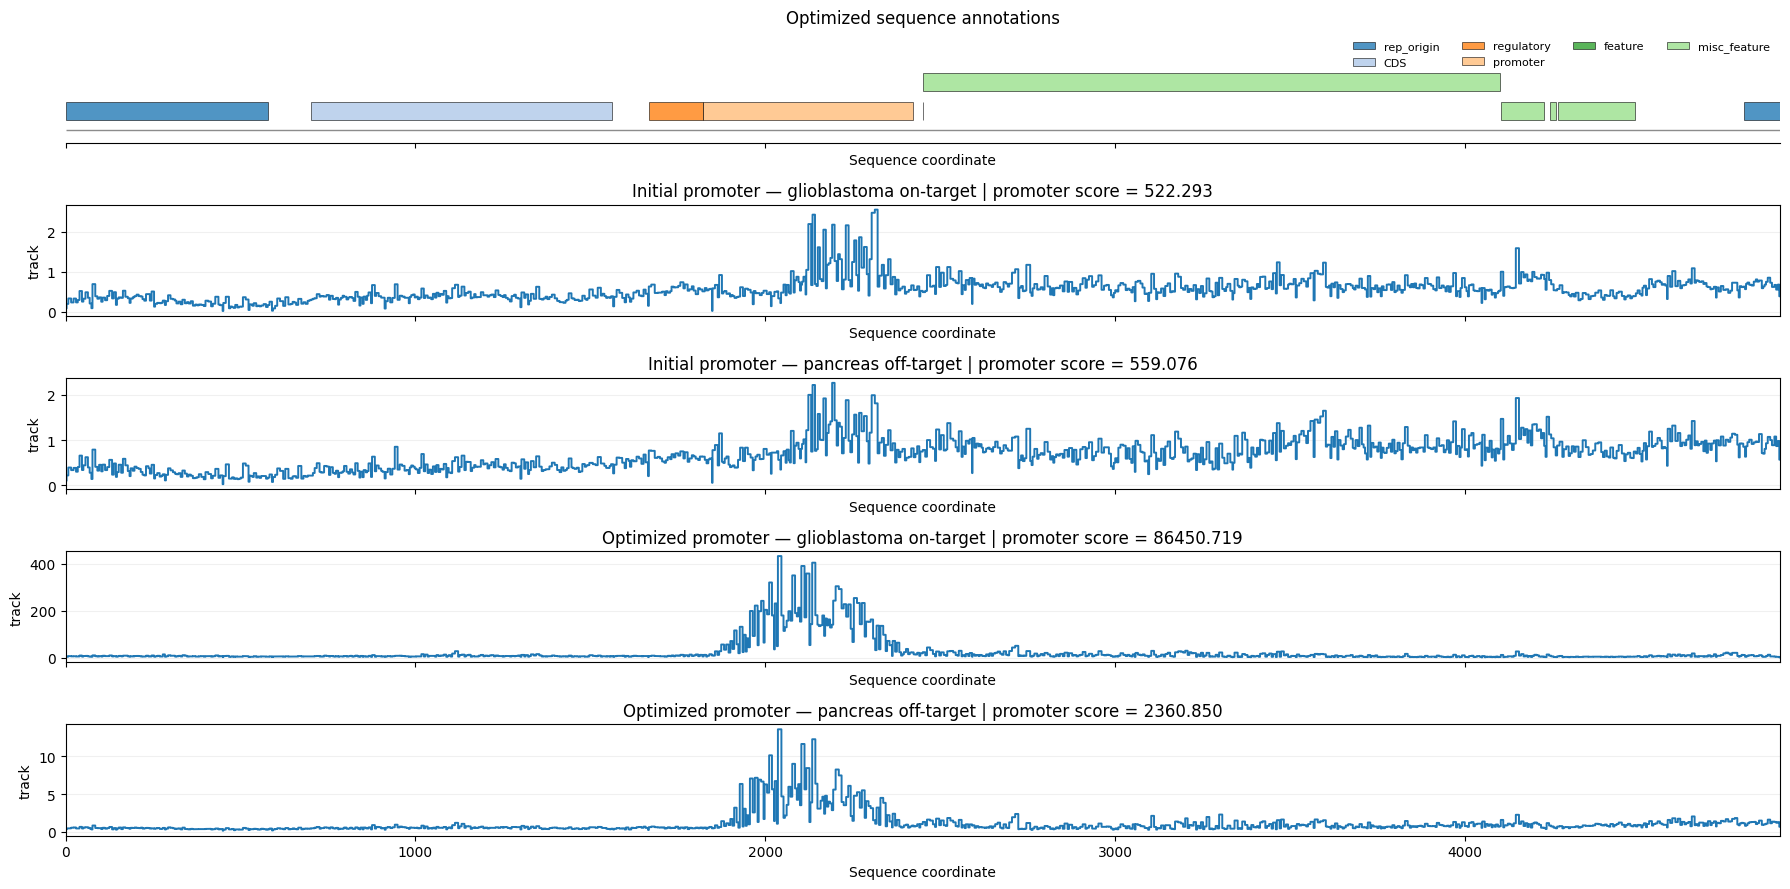

In [14]:
comparison_predictions = [
    (
        "Initial promoter — glioblastoma on-target",
        initial_on_prediction,
    ),
    (
        "Initial promoter — pancreas off-target",
        initial_off_prediction,
    ),
    (
        "Optimized promoter — glioblastoma on-target",
        optimized_on_prediction,
    ),
    (
        "Optimized promoter — pancreas off-target",
        optimized_off_prediction,
    ),
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(18, 9),
    sharex=True,
)

best_sequence.plot_annotations(
    ax=axes[0],
    hide_types=(
        "source",
        "transcript",
        "genome_interval",
    ),
    label_features=False,
    title="Optimized sequence annotations",
)

for axis, (label, prediction) in zip(
    axes[1:],
    comparison_predictions,
):
    promoter_score = scorer_promoter_atacseq.score_prediction(
        prediction
    ).score

    prediction.track().plot(
        ax=axis,
        color_by_sign=False,
        title=(
            f"{label} | "
            f"promoter score = {promoter_score:.3f}"
        ),
    )

fig.tight_layout()
plt.show()

# Getting activity scores from a sequence

The model provides two related but different types of output:

1. **Expression prediction** — one scalar describing the predicted expression level for the complete sequence and biological condition.
2. **ATAC-seq track** — position-dependent values describing predicted chromatin accessibility along the sequence.

A scorer converts either the expression output or part of the ATAC-seq track into a convenient activity score.

In [ ]:
# Replace this with any compatible AnnotatedSequence.
sequence_for_activity = optimizer.best_sequence

# Activity is condition-dependent: the same DNA can receive different predictions
# in different cell types.
condition_for_activity = on_target_condition

activity_prediction = model.predict_sequence(
    sequence=sequence_for_activity,
    condition=condition_for_activity,
    center="tss",
    return_tokens=True,
    retention="full",
)

## Reading the predicted expression value

`predict_sequence()` returns an `ExpressionPrediction`.

The predicted expression value can be accessed in two equivalent ways:

- `prediction.expression` is the convenient expression-specific attribute.
- `prediction.scalar("expression")` is the general accessor for named scalar outputs.

The API returns the model output in the units used during model training. It does
not automatically guarantee that this number is raw TPM.

Check the training configuration before interpreting the value as TPM,
`log(TPM)`, `log1p(TPM)`, or another normalized target.

In [ ]:
expression_value = activity_prediction.expression
expression_from_scalar = activity_prediction.scalar("expression")

print("Expression attribute:", expression_value)
print("Scalar accessor:", expression_from_scalar)

# A convenient one-row table containing sequence, condition, and expression.
display(activity_prediction.to_frame())

Expression attribute: 0.0213623046875
Scalar accessor: 0.0213623046875


,condition,expression,sequence
0,ENCFF035CWS,0.021362,MK484104:4b70483d3ee5


## What are expression and TPM?

### Gene expression

Gene expression describes how strongly the information encoded by a gene is
being used to produce RNA. For a protein-coding gene, that RNA may subsequently
be translated into protein.

In this notebook, the expression output represents the model's predicted RNA
abundance for the sequence under the supplied biological condition.

Expression is not a property of DNA alone. The same sequence can have different
expression levels in different cell types because different transcription
factors and regulatory programs are active.

### TPM

TPM means **transcripts per million**. It is a common RNA-seq normalization that
accounts for both transcript length and sequencing depth.

Conceptually:

1. Divide the number of reads assigned to each transcript by its length in
   kilobases. This produces reads per kilobase, or RPK.
2. Add the RPK values for all transcripts in the sample.
3. Divide each transcript's RPK by that total and multiply by 1,000,000.

Therefore, the TPM values in one sample add up to approximately one million.

TPM is a relative abundance measure, not an absolute count of RNA molecules per
cell. A value of 100 TPM means that the transcript contributes a larger fraction
of the measured RNA pool than a transcript with 10 TPM.

## Scoring a single sequence

Single-sequence scorers implement:

`scorer.score_prediction(prediction)`

The returned `PredictionScoringResult` stores the final value in
`result.score`.

This differs from `scorer.score(pair_prediction)`, which compares a reference
and alternative sequence.

The following scorers support single-sequence predictions:

| Scorer | Single-sequence score |
|---|---|
| `ExpressionScorer` | Absolute predicted expression |
| `TrackWindowScorer` | ATAC activity in a coordinate window |
| `TrackFeatureScorer` | ATAC activity over named annotations |
| `TrackAllFeaturesScorer` | Separate ATAC score for every annotation |
| `ScorerSet` | Runs several compatible scorers together |

The following scorers require a reference/alternative pair and do not implement
single-sequence scoring:

- `ExpressionDeltaScorer`
- `TokenWindowScorer`
- `TrackEffectPeakScorer`
- `RegressionScorer`

`aggregate="max_abs_delta"` is also pair-specific, even when used with
`TrackWindowScorer` or `TrackFeatureScorer`.

In [ ]:
# Global expression output.
expression_scorer = ExpressionScorer(
    transform="none",
)

# Sum of the predicted ATAC signal across the annotated promoter.
promoter_activity_scorer = TrackFeatureScorer(
    features="promoter",
    track="atac",
    aggregate="sum",
)

# Mean predicted ATAC signal in a 500 bp window around the TSS.
tss_activity_scorer = TrackWindowScorer(
    center="tss",
    width_bp=500,
    track="atac",
    aggregate="mean",
)

Each scorer can be called individually. The result contains more than the final
number: it also records the condition, sequence, scoring window, and scorer
configuration.

In [ ]:
expression_result = expression_scorer.score_prediction(
    activity_prediction
)
promoter_activity_result = (
    promoter_activity_scorer.score_prediction(
        activity_prediction
    )
)
tss_activity_result = tss_activity_scorer.score_prediction(
    activity_prediction
)

print("Expression score:", expression_result.score)
print(
    "Promoter ATAC sum:",
    promoter_activity_result.score,
)
print(
    "Mean ATAC around the TSS:",
    tss_activity_result.score,
)

Expression score: 0.0213623046875
Promoter ATAC sum: 1454.107421875
Mean ATAC around the TSS: 2.91365625


## Running several scorers together

`ScorerSet` applies several compatible scorers to the same prediction and
returns a named report.

This is useful when one sequence should receive expression, promoter activity,
and TSS-window activity scores without manually managing each result.

In [ ]:
activity_scorers = ScorerSet(
    {
        "expression": expression_scorer,
        "promoter_atac_sum": promoter_activity_scorer,
        "tss_atac_mean": tss_activity_scorer,
    }
)

activity_report = activity_scorers.score_prediction(
    activity_prediction
)

# Dictionary containing only the final score from each scorer.
display(activity_report.scores())

# Table with score, sequence, and condition information.
display(activity_report.to_frame())

{'expression': 0.0213623046875,
 'promoter_atac_sum': 1454.107421875,
 'tss_atac_mean': 2.91365625}

,name,score,condition,sequence
0,expression,0.021362,ENCFF035CWS,MK484104:4b70483d3ee5
1,track_feature,1454.107422,ENCFF035CWS,MK484104:4b70483d3ee5
2,track_window,2.913656,ENCFF035CWS,MK484104:4b70483d3ee5


## What is ATAC-seq?

DNA inside a cell is packaged together with proteins into chromatin. Some
regions are tightly packed and difficult for regulatory proteins to access.
Other regions are open and accessible.

ATAC-seq uses the Tn5 transposase enzyme to insert sequencing adapters
preferentially into accessible DNA. Sequencing the resulting fragments reveals
where chromatin was open in the measured cell population.

An ATAC-seq peak is a region with substantially more accessibility signal than
its surroundings.

Common locations of ATAC-seq peaks include:

- **Promoters**, especially close to an active transcription start site;
- **Enhancers** that regulate genes from a distance;
- **Insulators and other regulatory elements**;
- regions occupied by active combinations of transcription factors.

For this plasmid example, the most biologically interesting signal is usually
around the inserted promoter and reporter TSS. If an enhancer were included in
the construct, it could also produce a separate accessible region.

A peak does not directly mean that RNA was produced. It means that the model
predicts the DNA region to be accessible under the supplied condition.
Accessibility often supports transcription, but expression additionally
depends on transcription factors, promoter architecture, enhancers, and the
surrounding biological context.

Likewise, a high peak does not by itself identify a particular transcription
factor. More specialized experiments or motif analyses are needed for that
interpretation.

Because this model was trained from genomic data, predictions over plasmid
backbone regions should be interpreted cautiously: plasmid context can differ
from ordinary chromosomal context.

## Visualizing sequence activity

The annotation panel shows where the promoter and TSS are located.

The ATAC panel shows the model's position-dependent accessibility prediction:

- the shaded region is the promoter used by `TrackFeatureScorer`;
- the dashed line marks the reporter TSS;
- high local values indicate predicted accessible regions;
- the promoter activity score is the aggregate of track values inside the
  shaded promoter interval.

The expression value and ATAC activity score use different scales and should not
be directly compared numerically.

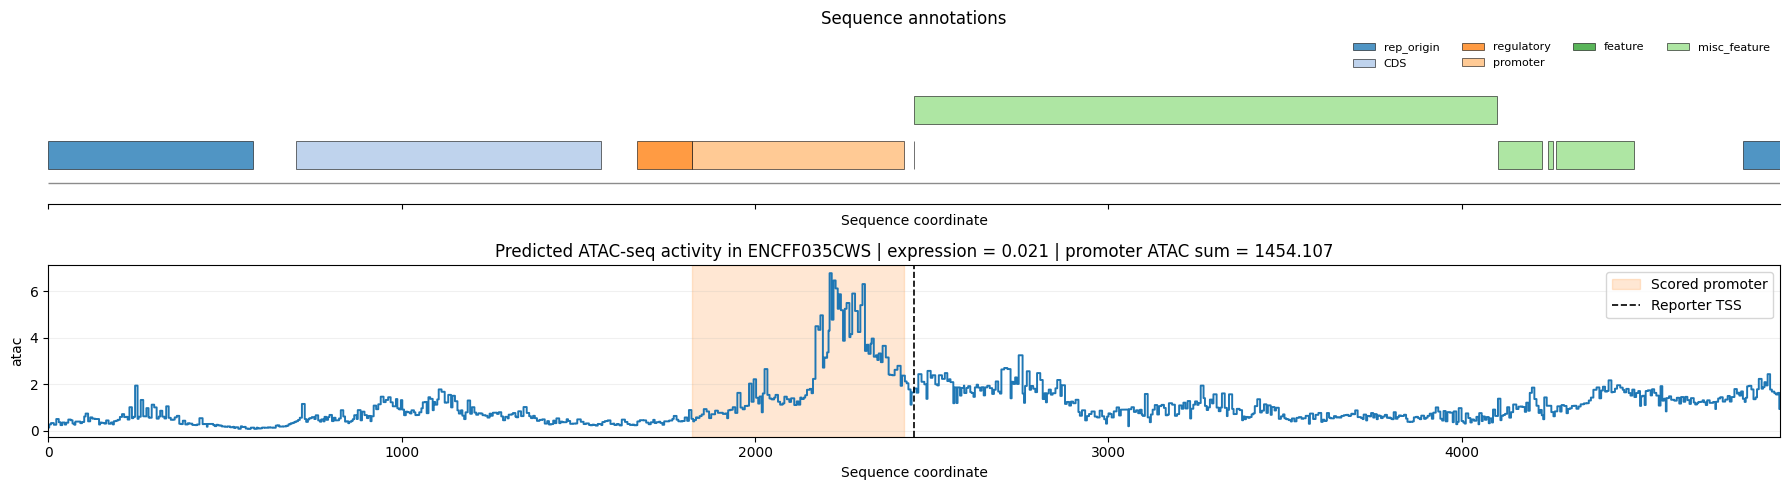

In [ ]:
promoter_feature = sequence_for_activity.feature(
    "promoter"
)
tss_feature = sequence_for_activity.feature("tss")

atac_track = activity_prediction.track("atac")

expression_score = activity_report["expression"].score
promoter_score = activity_report[
    "promoter_atac_sum"
].score

expression_text = (
    f"{expression_score:.3f}"
    if isinstance(expression_score, (int, float))
    else str(expression_score)
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(18, 5),
    sharex=True,
)

sequence_for_activity.plot_annotations(
    ax=axes[0],
    hide_types=(
        "source",
        "transcript",
        "genome_interval",
    ),
    label_features=False,
    title="Sequence annotations",
)

atac_track.plot(
    ax=axes[1],
    color_by_sign=False,
    title=(
        f"Predicted ATAC-seq activity in "
        f"{condition_for_activity.name} | "
        f"expression = {expression_text} | "
        f"promoter ATAC sum = {promoter_score:.3f}"
    ),
)

# Highlight the region included in the promoter score.
axes[1].axvspan(
    promoter_feature.start,
    promoter_feature.end,
    color="tab:orange",
    alpha=0.18,
    label="Scored promoter",
)

# Mark the reporter transcription start site.
axes[1].axvline(
    tss_feature.start,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Reporter TSS",
)

axes[1].legend(loc="upper right")

fig.tight_layout()
plt.show()

# Off-target penalty experiments

The original workflow above is kept unchanged. This section adds a controlled
comparison of alternative fitness functions and a reusable linear combination
of three scorers.

The new worst-case fitness is

$$
\operatorname{signed\_power}\!\left(\min_i s_i^{\mathrm{on}}, p_{\mathrm{on}}\right)
- \lambda\,
\operatorname{signed\_power}\!\left(\max_j s_j^{\mathrm{off}}, p_{\mathrm{off}}\right).
$$

For non-negative activity scores this is simply
`min(on_target) ** on_power - off_weight * max(off_target) ** off_power`.
Using the minimum and maximum makes the objective conservative when several
on-target or off-target conditions are supplied.

**Scale warning:** a power above 1 is not always a stronger penalty. For
`0 < off_target < 1`, squaring makes the penalty smaller; for
`off_target > 1`, squaring makes it larger. Therefore the comparison below
reports raw on-target and off-target scores and includes `off_weight` as an
independent penalty control.

In [ ]:
import polars as pl

from gena_expression import (
    LinearCombinationScorer,
    MinOnTargetMaxOffTargetFitness,
)

## Fitness functions to compare

`MinOnTargetMaxOffTargetFitness` is a callable object, so it is passed directly
to `SequenceOptimizer(fitness_function=...)`. The exact proposed objective is
included as `min(on) - max(off)^2`; nearby powers and an explicit weight show
whether any observed effect comes from the power or simply from a larger
off-target penalty.

The baseline value is `None`, which preserves the optimizer's existing
`mean(on) - mean(off)` behavior.

In [ ]:
FITNESS_FUNCTIONS = {
    "mean(on) - mean(off) [baseline]": None,
    "min(on) - max(off)": MinOnTargetMaxOffTargetFitness(
        on_power=1.0,
        off_power=1.0,
    ),
    "min(on) - max(off)^1.5": MinOnTargetMaxOffTargetFitness(
        on_power=1.0,
        off_power=1.5,
    ),
    "min(on) - max(off)^2": MinOnTargetMaxOffTargetFitness(
        on_power=1.0,
        off_power=2.0,
    ),
    "min(on) - 2*max(off)^2": MinOnTargetMaxOffTargetFitness(
        on_power=1.0,
        off_power=2.0,
        off_weight=2.0,
    ),
    "min(on) - max(off)^3": MinOnTargetMaxOffTargetFitness(
        on_power=1.0,
        off_power=3.0,
    ),
}

## Keep the comparison reproducible and affordable

Every objective receives the same generation-zero sequences, optimizer seed,
and reset offspring RNG. This isolates the fitness function as far as possible;
the later populations will still diverge because each objective selects
different parents.

The defaults below are an exploratory sweep smaller than the main run. Increase
them only after checking runtime and GPU memory. The original offspring
generator is reused rather than reimplemented.

In [ ]:
SWEEP_POPULATION_SIZE = 80
SWEEP_OFFSPRING_SIZE = 80
SWEEP_N_GENERATIONS = 6

# Reuse exactly the same initial candidates for every fitness function.
sweep_initial_population = initial_population[
    : SWEEP_POPULATION_SIZE - 1
]


def make_fitness_optimizer(fitness_function):
    # Build one fair, reproducible optimizer for the fitness sweep.

    global offspring_rng

    # The existing offspring_generator reads this global RNG at call time.
    offspring_rng = random.Random(RANDOM_SEED + 2)

    return SequenceOptimizer(
        sequence=optimization_sequence,
        region="promoter",
        tokenization_center="tss",
        scorer=scorer_promoter_atacseq,
        on_targets={ON_TARGET_KEY: on_target_condition},
        off_targets={OFF_TARGET_KEY: off_target_condition},
        offspring_generator=offspring_generator,
        fitness_function=fitness_function,
        population_size=SWEEP_POPULATION_SIZE,
        offspring_size=SWEEP_OFFSPRING_SIZE,
        n_generations=SWEEP_N_GENERATIONS,
        initial_population=sweep_initial_population,
        selection_strategy="top_k",
        elite_count=1,
        random_seed=RANDOM_SEED,
    )

## Run the matched fitness sweep

This cell performs one evolutionary run per objective. Each result remains in
`fitness_runs`, so its full `evaluations`, `history`, and `final_population`
tables can be inspected later.

In [ ]:
fitness_runs = {}

for objective_name, fitness_function in FITNESS_FUNCTIONS.items():
    print(f"Running: {objective_name}")
    experiment_optimizer = make_fitness_optimizer(
        fitness_function
    )
    experiment_optimizer.run_evolution(
        model=model,
        grouping="condition",
        preprocessing_workers=10,
        max_records_per_forward=SWEEP_POPULATION_SIZE,
        prefetch_batches=2,
        evaluation_chunk_size=SWEEP_POPULATION_SIZE,
    )
    fitness_runs[objective_name] = experiment_optimizer

## Does a harsher penalty actually decrease off-target activity?

Fitness values cannot be compared across powers because every formula has a
different numerical scale. Instead, this cell extracts the best candidate from
each run and compares three raw quantities:

- `min_on_target`: the weakest on-target condition; higher is better;
- `max_off_target`: the strongest off-target condition; lower is better;
- `raw_selectivity_gap`: `min_on_target - max_off_target`; higher is better.

`off_target_change_vs_baseline_pct` directly answers whether a tested objective
reduced the raw off-target score relative to the original mean-minus-mean
fitness. Negative values are improvements.

In [ ]:
comparison_rows = []

for objective_name, experiment_optimizer in fitness_runs.items():
    best_row = experiment_optimizer.top(1).row(
        0,
        named=True,
    )
    on_values = [
        float(value)
        for column, value in best_row.items()
        if column.startswith("on_target__")
    ]
    off_values = [
        float(value)
        for column, value in best_row.items()
        if column.startswith("off_target__")
    ]
    min_on_target = min(on_values) if on_values else 0.0
    max_off_target = max(off_values) if off_values else 0.0
    comparison_rows.append(
        {
            "objective": objective_name,
            "candidate_id": best_row["candidate_id"],
            "min_on_target": min_on_target,
            "max_off_target": max_off_target,
            "raw_selectivity_gap": (
                min_on_target - max_off_target
            ),
            "objective_fitness": float(best_row["fitness"]),
        }
    )

baseline_name = "mean(on) - mean(off) [baseline]"
baseline_off_target = next(
    row["max_off_target"]
    for row in comparison_rows
    if row["objective"] == baseline_name
)

for row in comparison_rows:
    row["off_target_change_vs_baseline_pct"] = (
        100.0
        * (row["max_off_target"] - baseline_off_target)
        / abs(baseline_off_target)
        if baseline_off_target != 0
        else None
    )

fitness_comparison = pl.DataFrame(comparison_rows).sort(
    "max_off_target"
)
display(fitness_comparison)

## Which fitness function works better?

There is no single winner unless the acceptable on-target loss is defined.
The first two printed winners show the two extremes. The constrained winner is
usually the most useful choice: it minimizes off-target activity while keeping
at least 90% of the baseline's worst on-target score. Adjust
`ON_TARGET_RETENTION_FRACTION` to reflect the biological requirement.

The scatter plot shows the trade-off directly. Desirable candidates are toward
the upper-left: high on-target activity and low off-target activity.

In [ ]:
lowest_off_target = fitness_comparison.sort(
    "max_off_target"
).row(0, named=True)
highest_selectivity = fitness_comparison.sort(
    "raw_selectivity_gap",
    descending=True,
).row(0, named=True)

baseline_min_on = fitness_comparison.filter(
    pl.col("objective") == baseline_name
).row(0, named=True)["min_on_target"]

ON_TARGET_RETENTION_FRACTION = 0.90
on_target_floor = (
    ON_TARGET_RETENTION_FRACTION * baseline_min_on
)
eligible = fitness_comparison.filter(
    pl.col("min_on_target") >= on_target_floor
)
constrained_winner = (
    eligible.sort("max_off_target").row(0, named=True)
    if eligible.height
    else None
)

print(
    "Lowest raw off-target:",
    lowest_off_target["objective"],
)
print(
    "Largest raw selectivity gap:",
    highest_selectivity["objective"],
)
print(
    f"Lowest off-target with min_on >= {on_target_floor:.4g}:",
    (
        constrained_winner["objective"]
        if constrained_winner is not None
        else "no objective met the on-target floor"
    ),
)

fig, ax = plt.subplots(figsize=(9, 6))
for row in comparison_rows:
    ax.scatter(
        row["max_off_target"],
        row["min_on_target"],
        s=70,
    )
    ax.annotate(
        row["objective"],
        (row["max_off_target"], row["min_on_target"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
ax.axhline(
    on_target_floor,
    color="black",
    linestyle="--",
    linewidth=1,
    label="on-target acceptance floor",
)
ax.set_xlabel("Maximum off-target score (lower is better)")
ax.set_ylabel("Minimum on-target score (higher is better)")
ax.set_title("Fitness-function trade-off")
ax.legend()
fig.tight_layout()
plt.show()

### Interpreting the result responsibly

A lower off-target value in this matched run supports the hypothesis that the
new penalty helps, but one random seed is not enough to establish robustness.
After narrowing the choices, repeat only the leading objectives with several
seeds and compare the distributions of `min_on_target` and `max_off_target`.
Also inspect the entire final Pareto trade-off rather than only one top row.

If all raw off-target scores are below 1, increase `off_weight` or normalize the
score before using powers; merely increasing `off_power` can weaken the
penalty.

# Linear combination of three scorers

`LinearCombinationScorer` accepts the requested API:

```python
LinearCombinationScorer({
    scorer_name: (scorer, coefficient),
    ...
})
```

It calls every component on the same prediction and returns one regular scalar
`PredictionScoringResult`:

$$
s_{\mathrm{combined}} = \sum_k c_k s_k.
$$

The optimizer can therefore use it without any special-case logic. Component
scores, coefficients, and weighted contributions are retained in
`result.provenance["components"]`.

The original notebook names the evolvable feature `promoter`, while the
requested scorer uses `features="insert"`. The next cell adds an `insert`
annotation over exactly the same coordinates; it does not change the DNA.

In [ ]:
promoter_feature_for_insert = optimization_sequence.feature(
    "promoter"
)
optimization_sequence_with_insert = (
    optimization_sequence.add_feature(
        name="insert",
        start=promoter_feature_for_insert.start,
        end=promoter_feature_for_insert.end,
        type="insert",
    )
)

# A sum over 501 bp is often roughly 501 times a mean-scale score, so the
# initial coefficient below is 1 / 501. Inspect the actual contributions in
# the next cell and tune all three coefficients for the trained model.
COMBINED_SCORER_COEFFICIENTS = {
    "tss_window": 1.0 / 501.0,
    "insert_mean": 1.0,
    "expression": 1.0,
}

combined_scorer = LinearCombinationScorer(
    {
        "tss_window": (
            TrackWindowScorer(
                center="tss",
                width_bp=501,
                aggregate="sum",
            ),
            COMBINED_SCORER_COEFFICIENTS["tss_window"],
        ),
        "insert_mean": (
            TrackFeatureScorer(
                features="insert",
                aggregate="mean",
            ),
            COMBINED_SCORER_COEFFICIENTS["insert_mean"],
        ),
        "expression": (
            ExpressionScorer(),
            COMBINED_SCORER_COEFFICIENTS["expression"],
        ),
    },
    name="combined_activity",
)

## Calibrate the coefficients before optimization

Track sums, track means, and expression outputs can have very different scales.
This cell scores the unoptimized sequence once and displays each weighted
contribution. Coefficients should reflect the desired biology and should avoid
letting one component dominate only because its units are larger.

In [ ]:
combined_reference_prediction = model.predict_sequence(
    sequence=optimization_sequence_with_insert,
    condition=on_target_condition,
    center="tss",
    return_tokens=True,
    retention="full",
)

combined_reference_result = combined_scorer.score_prediction(
    combined_reference_prediction
)
component_contributions = pl.DataFrame(
    [
        {"component": name, **details}
        for name, details in combined_reference_result.provenance[
            "components"
        ].items()
    ]
)

print("Combined reference score:", combined_reference_result.score)
display(component_contributions)

## Use the combined scorer in the regular optimizer

This configuration uses the exact min-on/max-off-squared objective. Because
the combined scorer contains track scorers, its `requires_tokens` property is
automatically true and `SequenceOptimizer` requests full retained predictions.

The same exploratory population size and generation count are reused here. The
cell only configures the run; the following cell starts the expensive model
work.

In [ ]:
# Reset the existing generator's RNG so this example is reproducible.
offspring_rng = random.Random(RANDOM_SEED + 2)

combined_optimizer = SequenceOptimizer(
    sequence=optimization_sequence_with_insert,
    region="insert",
    tokenization_center="tss",
    scorer=combined_scorer,
    on_targets={ON_TARGET_KEY: on_target_condition},
    off_targets={OFF_TARGET_KEY: off_target_condition},
    offspring_generator=offspring_generator,
    fitness_function=MinOnTargetMaxOffTargetFitness(
        on_power=1.0,
        off_power=2.0,
    ),
    population_size=SWEEP_POPULATION_SIZE,
    offspring_size=SWEEP_OFFSPRING_SIZE,
    n_generations=SWEEP_N_GENERATIONS,
    initial_population=sweep_initial_population,
    selection_strategy="top_k",
    elite_count=1,
    random_seed=RANDOM_SEED,
)

## Run the combined-scorer optimization

This uses the same batching options as the fitness sweep. The returned public
tables have one scalar combined score for each on/off condition, while detailed
component contributions can be recovered by rescoring selected final sequences.

In [ ]:
combined_optimizer.run_evolution(
    model=model,
    grouping="condition",
    preprocessing_workers=10,
    max_records_per_forward=SWEEP_POPULATION_SIZE,
    prefetch_batches=2,
    evaluation_chunk_size=SWEEP_POPULATION_SIZE,
)

display(combined_optimizer.summary())
display(combined_optimizer.top(10))

## Inspect why the best combined candidate scored well

The final cell predicts the best sequence under both biological conditions and
expands the combined score into its three contributions. This is essential for
detecting coefficient imbalance: a supposedly stronger composite scorer is not
useful if a single high-scale component silently controls every decision.

In [ ]:
best_combined_sequence = combined_optimizer.best_sequence
best_combined_predictions = model.predict_multiple_sequences(
    sequences=[best_combined_sequence, best_combined_sequence],
    conditions=[on_target_condition, off_target_condition],
    center="tss",
    grouping="sequence",
    max_records_per_forward=2,
    show_progress=False,
    return_tokens=True,
    retention="full",
)

best_component_rows = []
for role, prediction in zip(
    ("on_target", "off_target"),
    best_combined_predictions,
):
    result = combined_scorer.score_prediction(prediction)
    for component_name, details in result.provenance[
        "components"
    ].items():
        best_component_rows.append(
            {
                "condition_role": role,
                "component": component_name,
                **details,
                "combined_score": result.score,
            }
        )

display(pl.DataFrame(best_component_rows))